In [1]:
import sklearn
import numpy as np
import pandas as pd
import os
import datetime as dt
import sys 
import importlib
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from collections import Counter
sklearn.set_config(enable_metadata_routing=False)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
from xgboost import XGBClassifier, XGBRegressor
import time 
import pandas as pd
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import pearsonr
import plotly.express as px
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import pickle


############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables
from scripts import feature_selection as fs
from scripts import clustering as cl

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(cl)

# Filepaths
brighten_dir = paths.DATA
sub_dir = paths.SUB_DFS
results_dir = paths.RESULTS



################ DEFINE column variables from data ###################
from scripts.variables import id_columns
from scripts.variables import all_cols, all_daily_cols, weekly_cols, baseline_cols, drop_weekly_cols
from scripts.variables import daily_cols_v1, daily_v2_sensor_hr, daily_v2_weather, daily_cols_v2 
from scripts.variables import gad_cols, phq9_base, alc_cols, phq9_cols, phq2_cols, sleep_cols, gic_cols, sds_cols


# Define label variables
df_names = ['v1_day', 'v2_day', 'v1_week', 'v2_week']
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes


########################################## MODELS #######################################


# Models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
# Dummy baseline model
class GroupMeanRegressor(BaseEstimator, RegressorMixin):
	def fit(self, X, y, groups):
		self.group_means_ = y.groupby(groups.squeeze()).mean().squeeze()
		self.global_mean_ = y.mean().squeeze()
		return self
	
	def predict(self, X, groups):
		return groups.squeeze().map(self.group_means_).fillna(self.global_mean_).values

# Pearson scorer
def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

models = {
	'Random Forest': RandomForestRegressor(random_state=42),
	'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
	'Hist Gradient Boost': HistGradientBoostingRegressor(),
	'Group Mean': GroupMeanRegressor(),
	'Ridge': Ridge(alpha=1.0)
}
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr

def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

scoring_metrics = {
	'r2': 'r2',
	'neg_mae': 'neg_mean_absolute_error',
	'neg_rmse': 'neg_root_mean_squared_error',
}





In [2]:
# Just so i can view them :3
a_v1day_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v1_day_trainval_pca.csv'))
a_v1week_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v1_week_trainval_pca.csv'))
a_v2day_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v2_day_trainval_pca.csv'))
a_v2week_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v2_week_trainval_pca.csv'))


## Subject-Level ANOVA, Averaged Across All Subjects

Run on: Wed 27 May 2026, 04:39PM
################ v1_day ###############


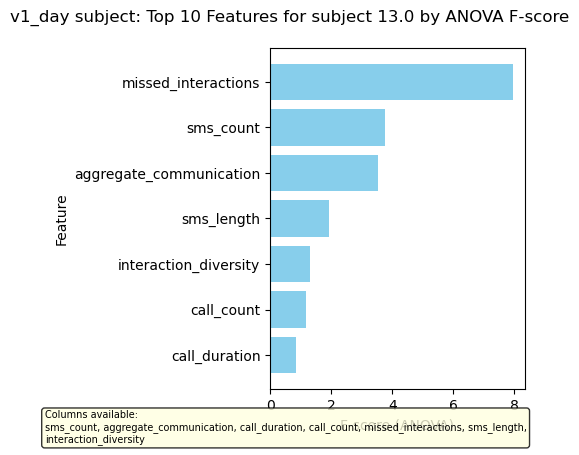

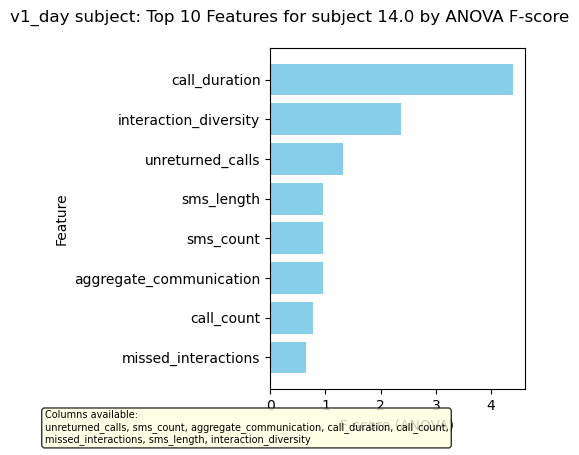

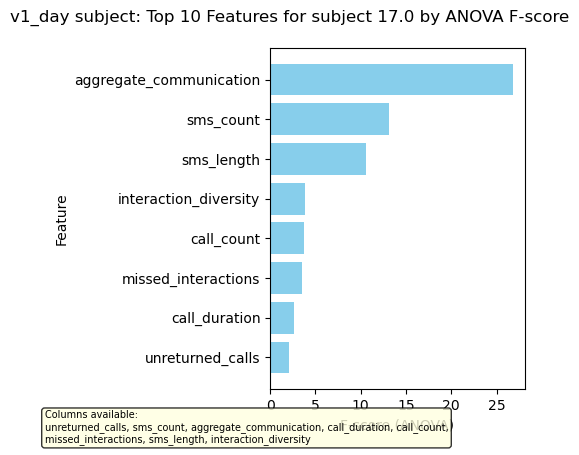

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


################ v2_day ###############


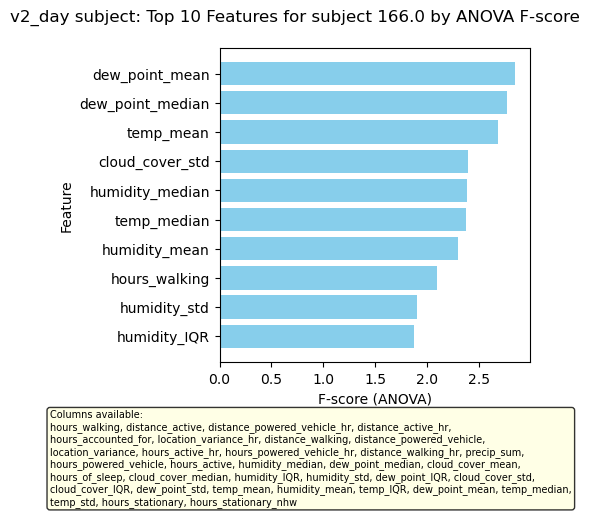

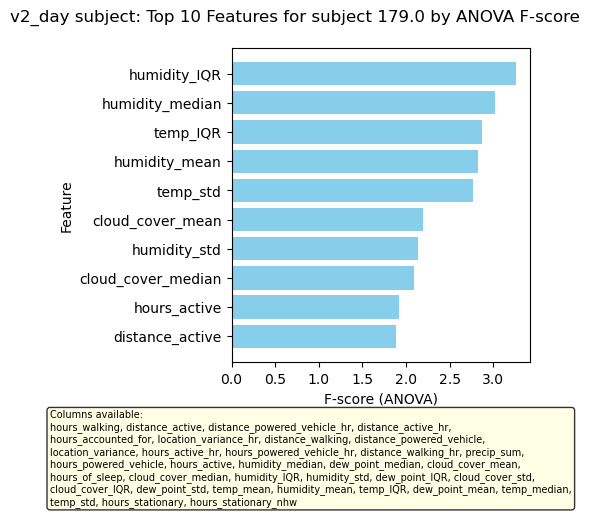

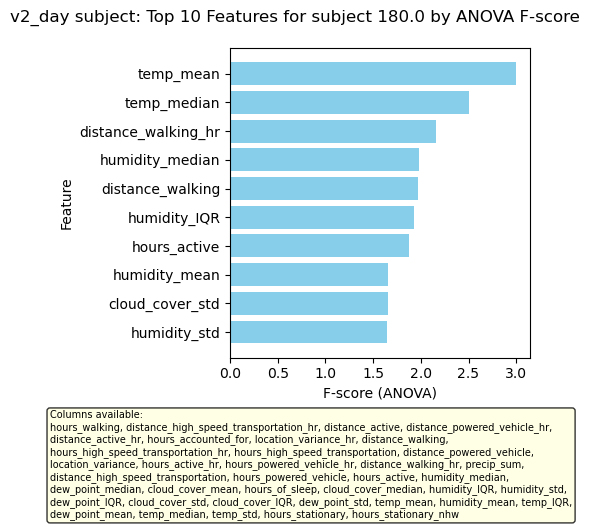

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


################ v1_week ###############


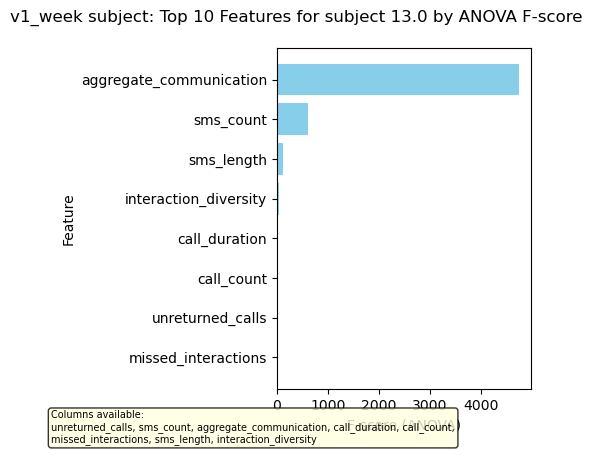

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


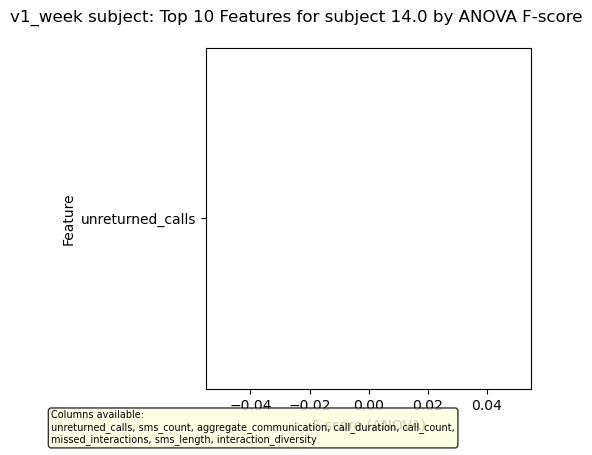

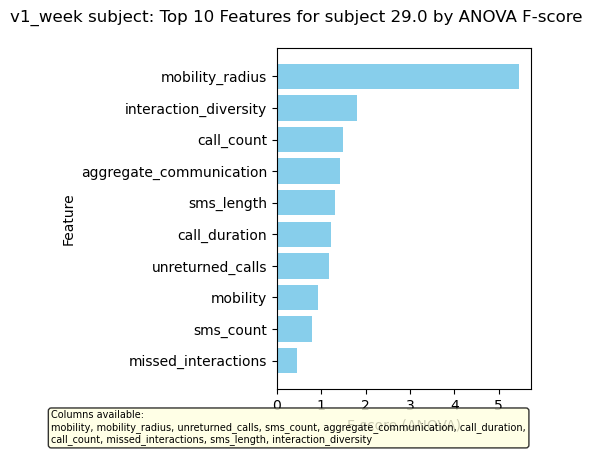

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj

################ v2_week ###############


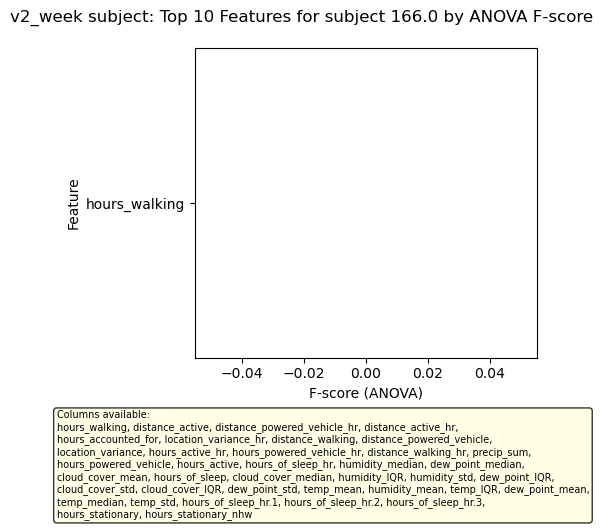

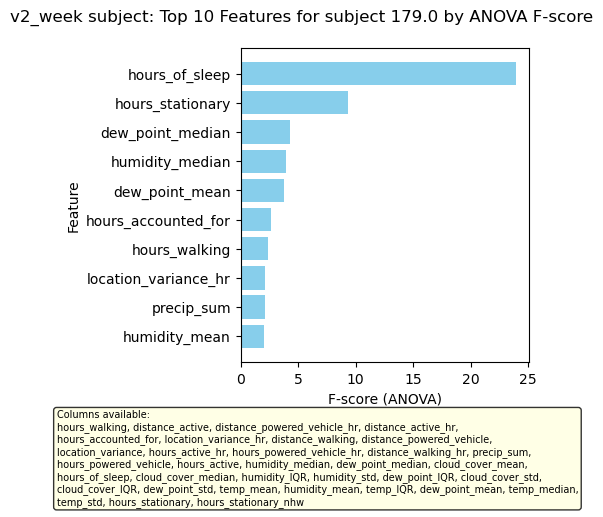

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


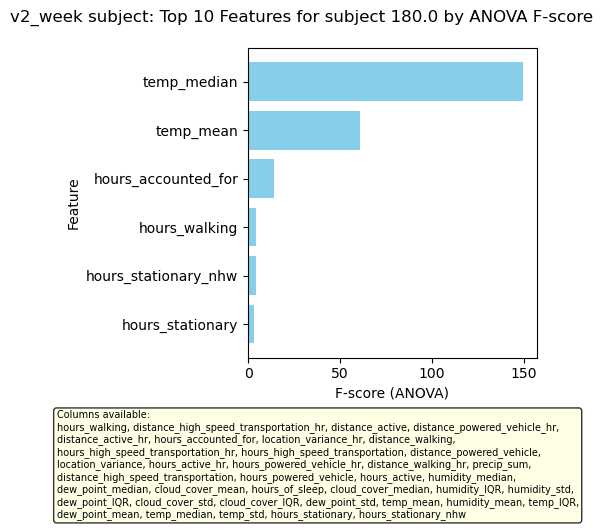

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj

For v1_day: 164 used of 203


For v2_day: 103 used of 142


For v1_week: 150 used of 189


For v2_week: 108 used of 147
################ v1_day ###############


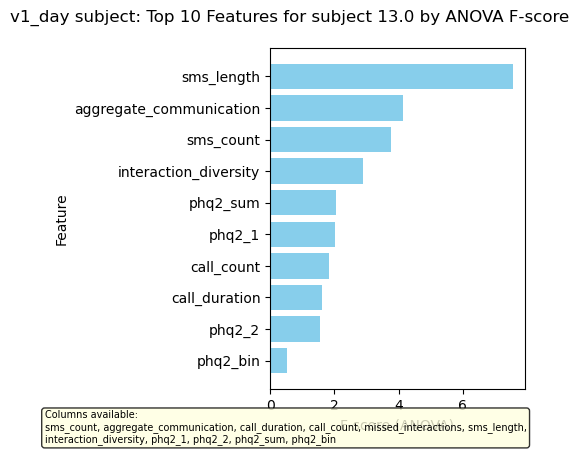

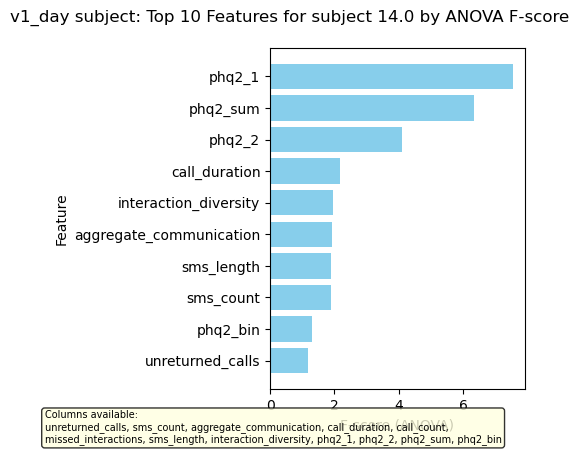

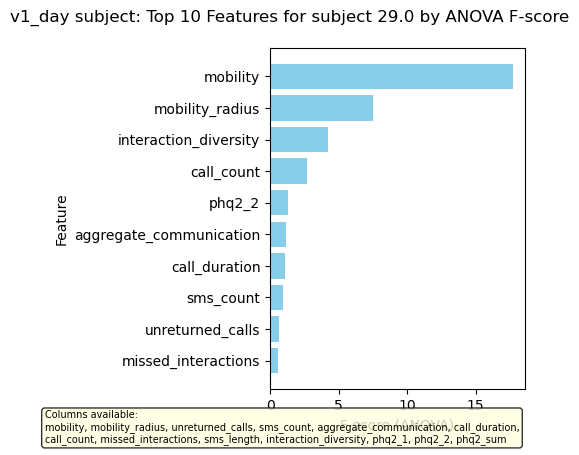

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs

################ v2_day ###############


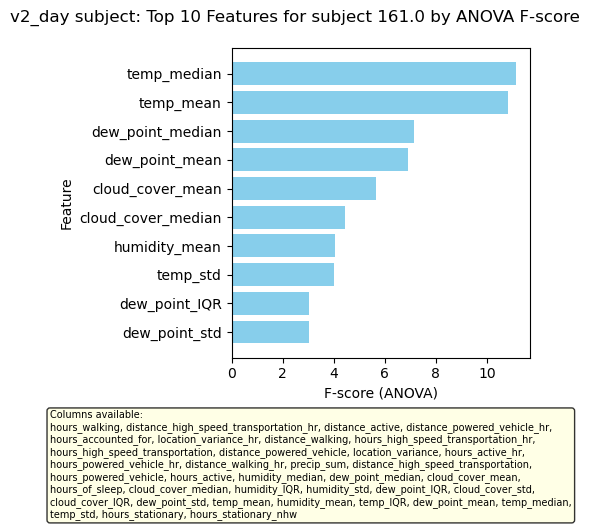

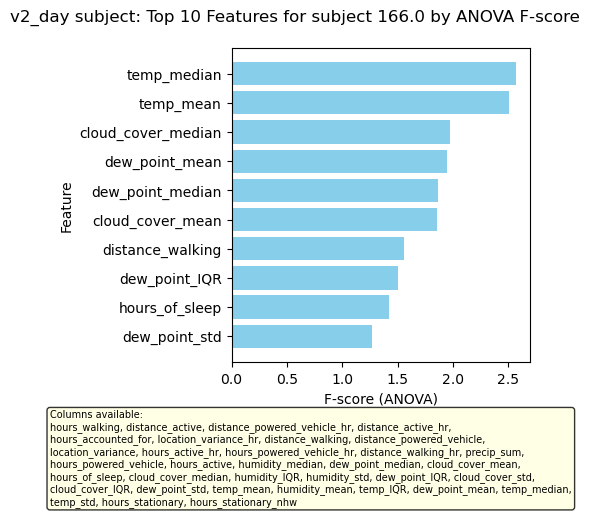

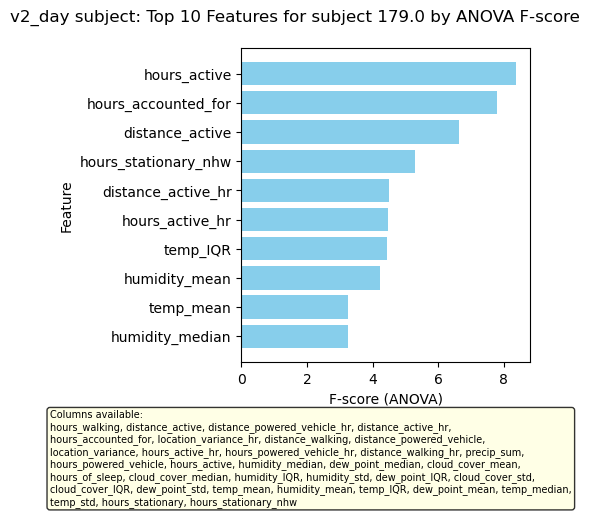

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs

################ v1_week ###############


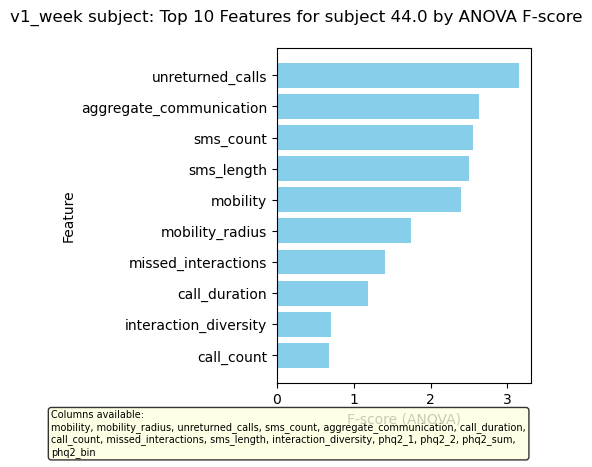

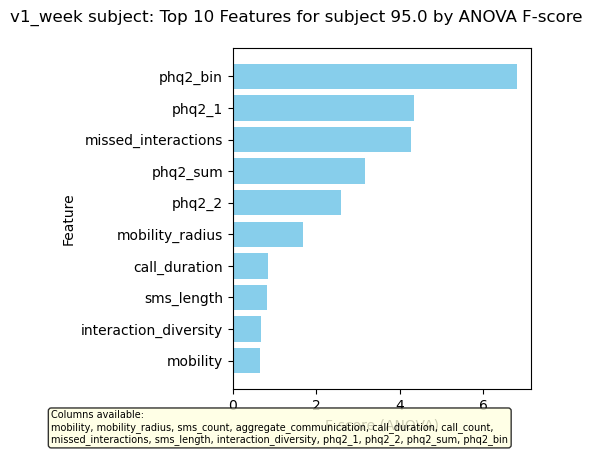

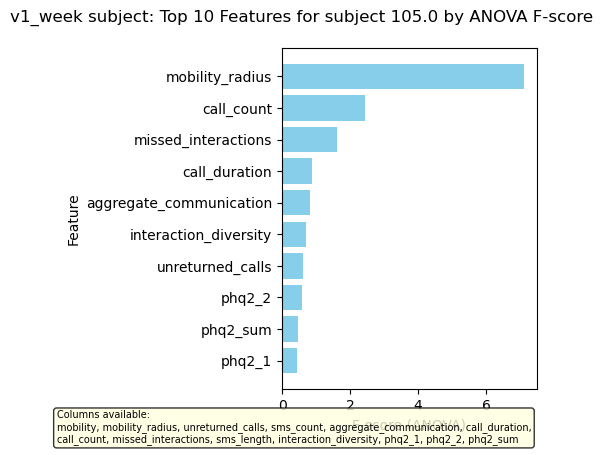

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs

################ v2_week ###############


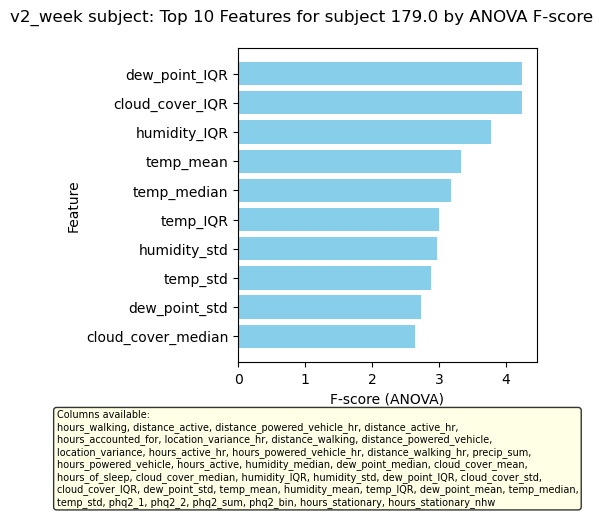

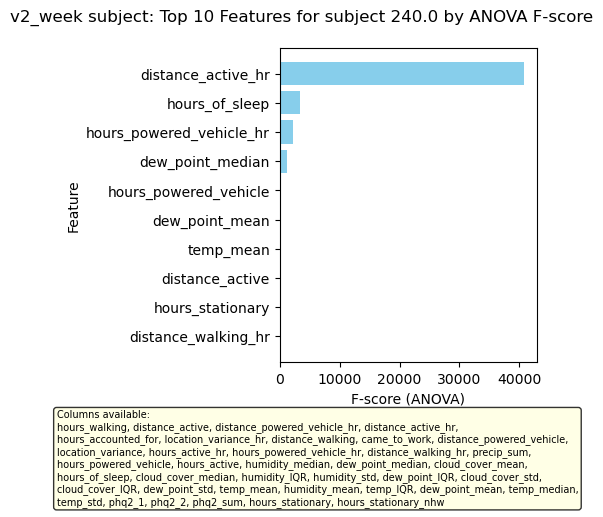

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


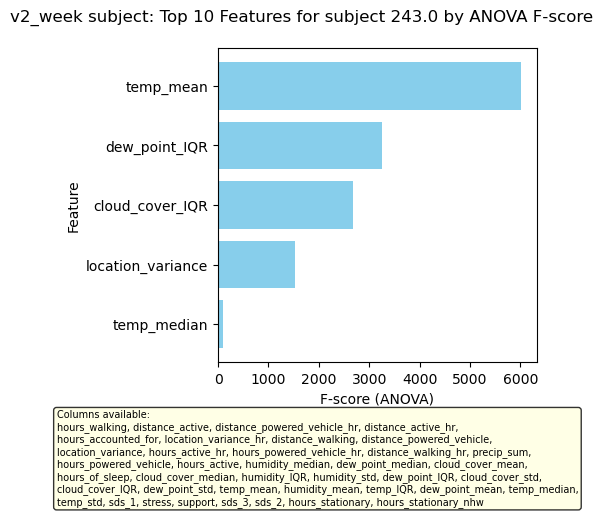

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/minic

For v1_day: 141 used of 269


For v2_day: 83 used of 211


For v1_week: 42 used of 170


For v2_week: 19 used of 147


In [3]:
## Anova for feature analysis
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
import textwrap

# ---- EDIT PARAMS ------
n_features = 10 # Choose number of features/scores to save from the ANOVA
n_subjects_show = 3 # Choose number of subjects' ANOVA scores to see in graphs
n_features_show = 10 # Choose number of features to see in graphs
show_means = True # Choose whether to visualize mean scores for features across all subjects
verbose = False
# --------------------

anova_features = {}
top_subj_features = {}
	
for y_col in ['phq2_sum','phq9_sum']:
	anova_features[y_col] = {}
	top_subj_features[y_col]={}

	for name in ['v1_day','v2_day','v1_week','v2_week']:
		subjects_shown_count=0
		subjects_skipped=0
		top_subj_features[y_col][name] = {}
		print(f'################ {name} ###############')
		df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')) #use transformed to have NOT imputed data
		for sub, sub_df in df.groupby('num_id'):
			
			sub_df_anova = sub_df.drop(columns=[col for col in sub_df.columns if 'Unnamed' in col or '_nan' in col or '_indicator' in col or col in ['day','week','month']+id_columns])
			sub_df_anova = sub_df_anova.drop(columns=[col for col in sub_df_anova.columns if any(item in col for item in baseline_cols) or 'season' in col or 'cohort' in col or 'dt' in col or 'user_phone_type' in col or 'base' in col])
			sub_df_anova = sub_df_anova.drop(columns=[col for col in sub_df_anova.columns if col in id_columns])


			df_cov = sub_df_anova.loc[:, sub_df_anova.notna().mean() > 0.7]
			df_cov = df_cov.copy()
			if y_col not in df_cov.columns:
				df_cov[y_col] = sub_df_anova[y_col].copy()
			#print(f'Not including these columns in X, not enough coverage: ', [col for col in sub_df_anova.columns if col not in df_cov.columns])
			df_full = df_cov.dropna()
			#print(f'Shape before dropna: {df_cov.shape}, shape afer dropna: {df_full.shape}')
			rows = len(df_full)
			columns_dropped = df_cov.shape[0] - df_full.shape[0]
			columns_remaining = df_full.shape[0]
			min_rows = 6 if 'week' in name else 15
			if rows <= min_rows:
				if verbose: print(f'Skipping {sub}, only {rows} rows.')
				subjects_skipped+=1
				continue # skip small samples
			if columns_remaining < 4:
				if verbose: print(f'Skipping {sub}, only {columns_remaining} columns (dropped {columns_dropped}).')
				subjects_skipped+=1
				continue #skip insufficient features

			# Separate X and y
			selector = SelectKBest(score_func=f_classif, k=2)
			if 'phq2' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq' in col])
			if 'phq9' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq9' in col])
			X_num = X.select_dtypes(include=('int64','float64'))
			# print(f'Not including these columns in X, not numeric: ', [col for col in X.columns if col not in X_num.columns])
			
			y = df_full[y_col].copy()
			if y.nunique() < 2 or y.var() < 0.001:
				if verbose: print(f'Skipping sub {sub}: 0 variance in y')
				subjects_skipped+=1
				continue
			if y.std() < 0.1:
				if verbose: print(f'Skipping sub {sub}, low variance in y')
				subjects_skipped+=1
				continue



			# --- Drop constant (zero-variance) features ---
			var_selector = VarianceThreshold(threshold=1e-10)
			try:
				X_var = pd.DataFrame(
					var_selector.fit_transform(X_num),
					columns=X_num.columns[var_selector.get_support()],
					index=X_num.index
				)
			except Exception as e:
				if verbose: print(f'Skipping sub {sub}, Exception on VarianceThreshold: {e}')
				subjects_skipped+=1
				continue 

			if X_var.shape[1] < 2:
				if verbose: print(f'Skipping sub {sub}, only {X_var.shape[1]} features after dropping zero-variance.')
				subjects_skipped+=1
				continue

			X_new = selector.fit_transform(X_var, y)

			# Show scores
			anova_scores = pd.DataFrame({
				'feature': X_var.columns,
				'f_score': selector.scores_,
				'p_value': selector.pvalues_
			}).sort_values('f_score', ascending=False)

			#print(anova_scores)
			
			# --- Save Features --- 
			top_n = 10  # number of top features to save
			top_features_sub = anova_scores.head(top_n)
			top_subj_features[y_col][name][sub] = top_features_sub['feature'].to_list()

			# --- Visualize Scores for Subjects ---

			if subjects_shown_count < n_subjects_show:
				fig = plt.figure(figsize=(5, 4))
				plt.barh(top_features_sub['feature'], top_features_sub['f_score'], color='skyblue')
				plt.xlabel('F-score (ANOVA)')
				plt.ylabel('Feature')
				plt.suptitle(f'{name} subject: Top {top_n} Features for subject {sub} by ANOVA F-score')
				plt.gca().invert_yaxis()

				# Wrap columns into a readable multi-line string
				cols_str = ', '.join(X_var.columns.to_list())
				wrapped = textwrap.fill(cols_str, width=100)
				label = f'Columns available:\n{wrapped}'

				plt.figtext(
					0.01, -0.02,          # x, y in figure coords (below the axes)
					label,
					fontsize=7,
					verticalalignment='top',
					bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
				)

				plt.tight_layout()
				plt.subplots_adjust(bottom=0.02 + 0.013 * wrapped.count('\n'))  # grow bottom margin with line count
				plt.show()
				subjects_shown_count += 1


	# --- Summarize across subjects ---
	for name in top_subj_features[y_col].keys():
		all_feats = [feat for sublist in top_subj_features[y_col][name].values() for feat in sublist]
		counts = Counter(all_feats)
		top_common = pd.DataFrame(counts.most_common(15), columns=['feature', 'count'])
		
		# --- Visualize Mean Scores Across Subjects ---
		if show_means:
			fig = px.bar(top_common, x='feature', y='count', title=f'Top 15 sig. features to {y_col}  for {name}')
			fig.show()

		if verbose: print(f'Adding to {name} for {y_col}: {top_common['feature'].to_list()}')
		anova_features[y_col][name] = top_common['feature'].to_list()

		subjects_used = len(list(top_subj_features[y_col][name].keys()))
		subjects = subjects_used + subjects_skipped

		print(f'For {name}: {subjects_used} used of {subjects}')
	


## Linear Mixed-Effects Model for feature analysis


In [4]:
## Linear Mixed-Effects Model for feature analysis
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

import pandas as pd
import numpy as np
from collections import Counter
import statsmodels.formula.api as smf
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# ---- EDIT PARAMS ------
n_features_show = 15       # Number of top features to display in summary plots
show_means = True          # Whether to visualize population-level feature importance
min_subjects_per_feature = 3  # Feature must appear in at least this many subjects' data
coverage_threshold = 0.7   # Min non-null proportion to keep a column
# --------------------

lme_features = {}

for y_col in ['phq2_sum', 'phq9_sum']:
	lme_features[y_col] = {}

	for name in ['v1_day', 'v2_day', 'v1_week', 'v2_week']:
		print(f'################ {name} ###############')
		df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
		print(f'Reading in df from {os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')}')

		# ---- Clean columns (same logic as before) ----
		drop_patterns = ['Unnamed', '_nan', '_indicator', 'season', 'cohort', 'dt',
						 'user_phone_type', 'base']
		drop_exact = ['day', 'week', 'month'] + [col for col in id_columns if 'num_id' not in col] + baseline_cols

		df_clean = df.drop(columns=[
			col for col in df.columns
			if any(p in col for p in drop_patterns)
			or col in drop_exact
			or any(item in col for item in baseline_cols)
		], errors='ignore')

		# ---- Keep columns with sufficient coverage across the whole dataset ----
		df_clean = df_clean.loc[:, df_clean.notna().mean() > coverage_threshold]
		if y_col not in df_clean.columns:
			df_clean[y_col] = df[y_col]

		# ---- Drop PHQ co-predictors depending on target ----
		if 'phq2' in y_col:
			X_cols = [col for col in df_clean.columns if 'phq' not in col and col != 'num_id']
		else:
			X_cols = [col for col in df_clean.columns if 'phq9' not in col and col != 'num_id']

		# Keep numeric features only, but explicitly preserve num_id and target
		feature_cols_numeric = df_clean[X_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
		df_model = df_clean[feature_cols_numeric + [y_col, 'num_id']].copy()
		df_model = df_model.dropna()

		# ---- Drop zero/near-zero variance features ----
		feature_cols = [col for col in df_model.columns if col not in [y_col, 'num_id']]
		var_selector = VarianceThreshold(threshold=1e-10)
		X_var = pd.DataFrame(
			var_selector.fit_transform(df_model[feature_cols]),
			columns=np.array(feature_cols)[var_selector.get_support()],
			index=df_model.index
		)

		# ---- Require feature appears in enough subjects' rows ----
		subject_coverage = df_model[['num_id']].join(X_var).groupby('num_id').count()
		valid_features = subject_coverage.columns[
			(subject_coverage > 0).sum() >= min_subjects_per_feature
		].tolist()
		X_var = X_var[valid_features]

		if X_var.shape[1] < 2:
			print(f'  Skipping {name}/{y_col}: too few valid features after filtering.')
			continue

		# ---- Standardize features (LME coefficients are comparable when scaled) ----
		scaler = StandardScaler()
		X_scaled = pd.DataFrame(
			scaler.fit_transform(X_var),
			columns=X_var.columns,
			index=X_var.index
		)

		df_lme = X_scaled.copy()
		df_lme[y_col] = df_model[y_col].values
		df_lme['num_id'] = df_model['num_id'].values

		# ---- Fit one LME per feature (univariate), random intercept per subject ----
		# Univariate approach avoids multicollinearity and is standard for feature selection
		lme_results = []
		for feat in X_scaled.columns:
			try:
				formula = f'{y_col} ~ {feat}'
				model = smf.mixedlm(formula, df_lme, groups=df_lme['num_id'])
				result = model.fit(reml=False, method='lbfgs', disp=False)

				lme_results.append({
					'feature': feat,
					'coefficient': abs(result.fe_params[feat]),  # abs for ranking magnitude
					'z_score': abs(result.tvalues[feat]),
					'p_value': result.pvalues[feat],
					'converged': result.converged
				})
			except Exception as e:
				# Skip features where the model fails to converge or errors out
				print(f'  LME failed for {feat}: {e}')

		if not lme_results:
			print(f'  No LME results for {name}/{y_col}.')
			continue

		lme_scores = (
			pd.DataFrame(lme_results)
			.query('converged == True')
			.sort_values('z_score', ascending=False)
			.reset_index(drop=True)
		)

		print(lme_scores.head(n_features_show).to_string(index=False))

		top_features_list = lme_scores.head(n_features_show)['feature'].tolist()
		lme_features[y_col][name] = top_features_list

		# ---- Visualize population-level feature importance ----
		if show_means:
			fig = px.bar(
				lme_scores.head(n_features_show),
				x='feature', y='z_score',
				error_y=None,
				title=f'Top {n_features_show} features for {y_col} | {name} (LME z-score)',
				labels={'z_score': '|z-score| (fixed effect)', 'feature': 'Feature'}
			)
			fig.show()

Run on: Wed 27 May 2026, 04:39PM
################ v1_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/

                feature  coefficient  z_score  p_value  converged
    missed_interactions     0.022361 2.395779 0.016585       True
          call_duration     0.023816 2.347803 0.018885       True
  interaction_diversity     0.020527 1.790946 0.073302       True
       unreturned_calls     0.012314 1.359120 0.174109       True
             call_count     0.010123 0.848665 0.396068       True
             sms_length     0.007898 0.664917 0.506104       True
        income_lastyear     0.030182 0.611631 0.540782       True
aggregate_communication     0.003188 0.251756 0.801230       True
              sms_count     0.001688 0.133486 0.893809       True


################ v2_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/

...

################ v2_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_week_trainval_transformed.csv
  LME failed for hours_of_sleep_hr.1: invalid syntax (<unknown>, line 1)
  LME failed for hours_of_sleep_hr.2: invalid syntax (<unknown>, line 1)
  LME failed for hours_of_sleep_hr.3: invalid syntax (<unknown>, line 1)
                              feature  coefficient  z_score  p_value  converged
                        dew_point_std     0.063944 2.569506 0.010184       True
                      humidity_median     0.083508 2.540178 0.011080       True
                        humidity_mean     0.078975 2.392185 0.016748       True
                        dew_point_IQR     0.057221 2.321145 0.020279       True
                             temp_std     0.044379 1.566737 0.117176       True
                             temp_IQR     0.042678 1.505914 0.132089       True
     

################ v1_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv
                feature  coefficient  z_score  p_value  converged
    missed_interactions     0.042702 4.256677 0.000021       True
       unreturned_calls     0.037098 3.814674 0.000136       True
               phq2_bin     0.034240 3.015951 0.002562       True
             call_count     0.022240 1.865208 0.062152       True
  interaction_diversity     0.021078 1.754701 0.079310       True
aggregate_communication     0.020601 1.408459 0.158995       True
               phq2_sum     0.014593 1.257271 0.208656       True
                 phq2_1     0.014163 1.250685 0.211049       True
              sms_count     0.017748 1.215305 0.224250       True
                 phq2_2     0.012261 1.088310 0.276458       True
             sms_length     0.012133 0.887518 0.374800      

################ v2_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv
                              feature  coefficient  z_score  p_value  converged
                            temp_mean     0.048772 2.762945 0.005728       True
                         humidity_std     0.024370 2.652877 0.007981       True
                          temp_median     0.043991 2.530499 0.011390       True
                         humidity_IQR     0.022378 2.442824 0.014573       True
                      distance_active     0.024482 2.287437 0.022170       True
      hours_high_speed_transportation     0.018064 2.080085 0.037518       True
distance_high_speed_transportation_hr     0.018040 2.079056 0.037612       True
   distance_high_speed_transportation     0.018040 2.079056 0.037612       True
                       hours_of_sleep     0.016911 1.877784 0.0604

################ v1_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_week_trainval_transformed.csv
                feature  coefficient   z_score      p_value  converged
               phq2_sum     0.405434 11.174793 5.417655e-29       True
                 phq2_1     0.377145 10.703171 9.835367e-27       True
                 phq2_2     0.369466 10.132711 3.955279e-24       True
               phq2_bin     0.346686  9.702173 2.951456e-22       True
        mobility_radius     0.095046  3.229656 1.239392e-03       True
       unreturned_calls     0.062330  1.882560 5.976007e-02       True
    missed_interactions     0.068473  1.810991 7.014218e-02       True
        income_lastyear     0.069422  0.912678 3.614122e-01       True
             call_count     0.023751  0.551126 5.815474e-01       True
              sms_count     0.017304  0.417533 6.762883e-01       True
agg

################ v2_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_week_trainval_transformed.csv
  LME failed for hours_of_sleep_hr.1: invalid syntax (<unknown>, line 1)
  LME failed for hours_of_sleep_hr.2: invalid syntax (<unknown>, line 1)
  LME failed for hours_of_sleep_hr.3: invalid syntax (<unknown>, line 1)
                              feature  coefficient  z_score      p_value  converged
                             phq2_sum     0.387818 8.746756 2.195739e-18       True
                               phq2_1     0.378132 8.498944 1.913234e-17       True
                               phq2_2     0.308960 7.270620 3.578406e-13       True
                             phq2_bin     0.161631 3.701366 2.144422e-04       True
                 hours_stationary_nhw     0.106616 2.870367 4.099951e-03       True
                 location_variance_hr     0.090048 2.530316 1

In [7]:
import pickle
with open(os.path.join(brighten_dir,'anova_features.pkl'), 'wb') as f:
    pickle.dump(anova_features, f)
    
with open(os.path.join(brighten_dir,'top_subj_anova_features.pkl'), 'wb') as f:
    pickle.dump(top_subj_features, f)


with open(os.path.join(brighten_dir,'lme_features.pkl'), 'wb') as f:
    pickle.dump(lme_features, f)


my pipeline: 
1. remove outliers
4. apply log transform to skewed or wide-tailed data
5. remove too-skewed data
6. Impute
7. Scale
8. Drop columns with too few unique values or too little variance